# Milestone 1: Exploratory Data Analysis
**FEMA Individuals & Households Program (IHP) registrations, Hurricane Ian (DR-4673), Lee County, FL**

CAI 4105 Machine Learning, Fall 2026. This notebook covers the *Data Understanding* phase (CRISP-DM):
what the data is, how good it is, what it says, and what could go wrong.

**How to run:** Kernel → *Restart & Run All*. The very first run downloads the data from FEMA (~20 min);
after that it loads from a local cache in seconds. Every chart is also saved to `reports/figures/`.

**Reading guide:** each section has a plain-English note above the code saying *what we are checking and why it matters*.

> *AI-use disclosure:* this notebook was drafted with Claude Code (Anthropic) and reviewed by the team. See `docs/AI_USAGE.md`.

In [1]:
import sys
from pathlib import Path

# Find the repo root (the folder that contains "src") so imports work no matter where Jupyter starts.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from src.data.fetch_fema import load_ian_lee
from src.features.prepare import load_model_data
from src.utils.columns import (TARGET, ALL_ROLES, role_of, check_roles,
                               APPLICATION_FEATURES, INSPECTION_FEATURES, LEAKAGE)
from src.utils.plotting import set_style, save_fig, BLUE, ORANGE, GRAY, INK_SOFT

set_style()
pd.set_option("display.width", 160, "display.max_columns", 40, "display.max_rows", 120)
AQUA = "#1baf7a"

## 1. The dataset

- **Source:** OpenFEMA API, dataset *Individuals and Households Program – Valid Registrations (v2)*; each row is one household's application for FEMA disaster aid.
- **Slice we use:** disaster **DR-4673 (Hurricane Ian)**, county **Lee (County), FL**.
- **Important caveat from FEMA:** the file contains **only *valid* registrations**. So "not eligible" here means *a valid applicant who was not awarded IHP aid*, not a fraudulent or incomplete application.
- **Quality warning from FEMA:** this is raw operational data (NEMIS) and "subject to a small percentage of human error".
- **Citation:** FEMA. *OpenFEMA Dataset: Individuals and Households Program – Valid Registrations v2.* https://www.fema.gov/openfema-data-page/individuals-and-households-program-valid-registrations-v2

In [2]:
raw = load_ian_lee()          # cached after the first call
check_roles(raw.columns)      # every column must have a documented role (see src/utils/columns.py)

applied = pd.to_datetime(raw["appliedDate"], utc=True).dt.tz_localize(None)
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Applications received {applied.min().date()} to {applied.max().date()}")
print(f"Requirement check -> rows >= 1,000: {raw.shape[0] >= 1000} | features >= 10: {len(APPLICATION_FEATURES) >= 10}")
raw.head(3).T.head(20)

194,482 rows x 100 columns
Applications received 2022-09-27 to 2023-01-12
Requirement check -> rows >= 1,000: True | features >= 10: True


,0,1,2
incidentTypeCode,H,H,H
declarationDate,2022-09-29T00:00:00.000Z,2022-09-29T00:00:00.000Z,2022-09-29T00:00:00.000Z
disasterNumber,4673,4673,4673
county,Lee (County),Lee (County),Lee (County)
fips,12071,12071,12071
censusGeoid,120710702012,120710401271,120710501052
censusYear,2020,2020,2020
damagedStateAbbreviation,FL,FL,FL
damagedCity,ST JAMES CITY,LEHIGH ACRES,FORT MYERS
damagedZipCode,33956,33971,33908


## 2. What every column *is* (column roles)

FEMA gives us 100 columns, but they are **not** all fair game as model inputs. Many are *results* of the aid decision
(dollar amounts awarded, eligibility for sub-programs, denial reasons). We sorted every column into one role
(`src/utils/columns.py`, described in `docs/data_dictionary.md`):

| Role | Meaning |
|---|---|
| **target** | what we predict |
| **application** | self-reported when the person registers (Tier 1 features) |
| **inspection** | only known after a FEMA inspector / verification step (Tier 2 features) |
| **leakage** | outcomes of the decision itself: using them would be cheating |
| **id_or_constant** | identifiers, or identical on every row (we filtered to one disaster + county) |

In [3]:
roles = pd.Series({c: role_of(c) for c in raw.columns}, name="role")
print(roles.value_counts().to_string())
print("\nTier 1 (application) features:", len(APPLICATION_FEATURES), "| Tier 2 (inspection) features:", len(INSPECTION_FEATURES))

role
leakage           43
application       27
id_or_constant    15
inspection        14
target             1

Tier 1 (application) features: 27 | Tier 2 (inspection) features: 14


## 3. The target variable: `ihpEligible`

**Question the model answers:** *Given what we know about an applicant, will FEMA award them Individuals & Households Program aid?*

`ihpEligible = True` means the applicant received a housing (HA) and/or other-needs (ONA) award. We checked three things: is it balanced, is it clean, and what does "not eligible" actually consist of.

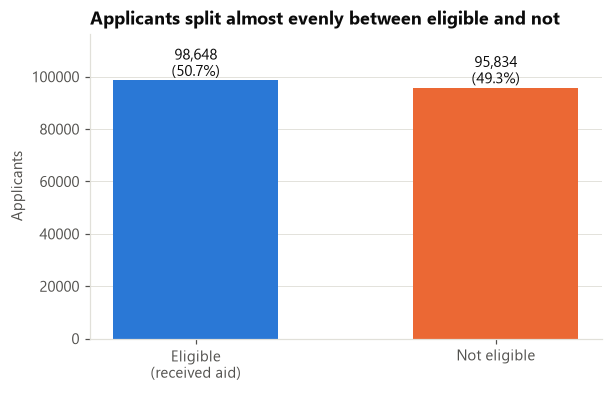

In [4]:
counts = raw[TARGET].value_counts().reindex([True, False])
share = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 3.6))
bars = ax.bar(["Eligible\n(received aid)", "Not eligible"], counts.values, color=[BLUE, ORANGE], width=0.55)
for b, n, s in zip(bars, counts.values, share.values):
    ax.text(b.get_x() + b.get_width() / 2, n, f"{n:,}\n({s:.1f}%)", ha="center", va="bottom")
ax.set_ylim(0, counts.max() * 1.18)
ax.set_ylabel("Applicants")
ax.grid(axis="x", visible=False)
ax.set_title("Applicants split almost evenly between eligible and not")
save_fig("target_balance"); plt.show()

**So what:** the classes are nearly balanced (~51% / 49%), which is unusual for real data and good news: plain accuracy is a meaningful score, and we don't need special tricks for class imbalance.

Next, a red flag. `ihpAmount` (dollars awarded) and `ihpEligible` might be the *same information*:

In [5]:
print(pd.crosstab(raw[TARGET], raw["ihpAmount"] > 0, rownames=["ihpEligible"], colnames=["ihpAmount > 0"]))

ihpAmount > 0  False  True 
ihpEligible                
False          95834      0
True               0  98648


**So what:** they are identical. Every eligible applicant got money, every ineligible one got $0. So `ihpAmount` can never be used to predict eligibility: it *is* eligibility. This is our first example of **data leakage**; Section 4 measures it for every column.

**Why were people ineligible?** FEMA records a high-level reason code for most (not all) ineligible applicants:

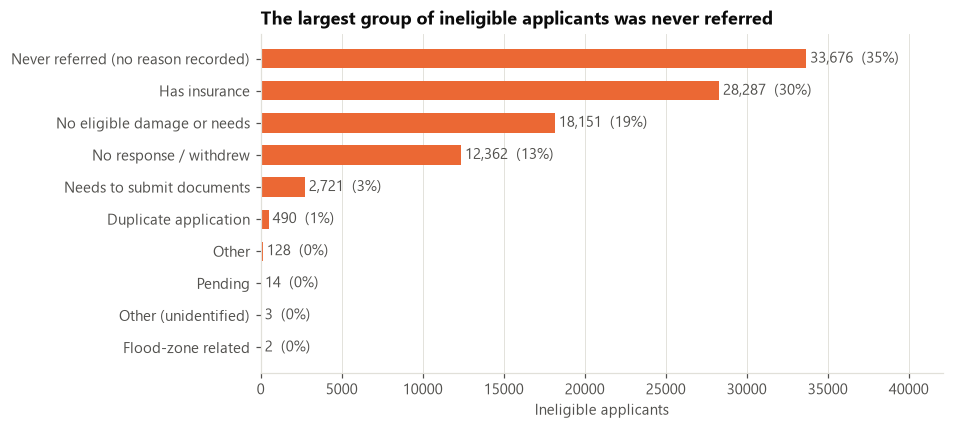

In [6]:
REASONS = {"1": "No eligible damage or needs", "2": "Has insurance", "3": "No response / withdrew",
           "4": "Needs to submit documents", "5": "Duplicate application", "6": "Flood-zone related",
           "7": "Other", "8": "Pending", "9": "Other (unidentified)"}
inel = raw[~raw[TARGET]]
reason = inel["ineligibleReason"].map(REASONS).fillna("Never referred (no reason recorded)")
r = reason.value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(r.index[::-1], r.values[::-1], color=ORANGE, height=0.6)
for y, v in enumerate(r.values[::-1]):
    ax.text(v, y, f" {v:,}  ({v / len(inel):.0%})", va="center", color=INK_SOFT)
ax.set_xlim(0, r.max() * 1.25); ax.grid(axis="y", visible=False)
ax.set_xlabel("Ineligible applicants")
ax.set_title("The largest group of ineligible applicants was never referred")
save_fig("ineligible_reasons"); plt.show()

**So what:** about 35% of ineligible applicants have *no* reason code, and these are exactly the applicants who were never referred to the program (`ihpReferral = False`; we checked, the two match on all 33,676 rows). Among those with a reason, insurance is the biggest (30% of all ineligible), then no eligible damage (19%) and no response or withdrawal (13%). Reason codes exist only for people who were already denied, so `ineligibleReason` is another leakage column. "Pending" (code 8) is a tiny share, so unfinished cases are not distorting the label much.

## 4. Leakage check: which columns give away the answer?

**Idea:** train a tiny model on *one column at a time* and see how well that single column predicts eligibility.
The score is **AUC**: 0.5 = coin flip, 1.0 = perfect. A single legitimate column rarely gets far above ~0.7. A column that scores 0.9+ is almost certainly a *result* of the decision, not a cause.

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def as_number(s):
    # Turn any column into numbers so a model can read it (text codes -> category codes; missing -> -1)
    kinds = set(s.dropna().map(type))
    if kinds and kinds <= {bool, np.bool_}:
        return s.map({True: 1.0, False: 0.0}).astype(float)
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(float)
    return s.astype("category").cat.codes.astype(float)

sample = raw.sample(60_000, random_state=42)     # a 60k sample keeps this section fast
y = sample[TARGET].astype(int)

scores = {}
for c in raw.columns:
    if c == TARGET:
        continue
    x = as_number(sample[c]).to_frame(c)
    if x[c].nunique() < 2:
        continue                                  # constant column: nothing to learn
    x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.3, stratify=y, random_state=0)
    model_1 = HistGradientBoostingClassifier(max_iter=40, random_state=0).fit(x_tr, y_tr)
    scores[c] = roc_auc_score(y_te, model_1.predict_proba(x_te)[:, 1])

auc = pd.DataFrame({"auc": pd.Series(scores)})
auc["role"] = [role_of(c) for c in auc.index]
auc = auc.sort_values("auc", ascending=False)
print(auc.groupby("role")["auc"].agg(["count", "max", "median"]).round(3))

                count    max  median
role                                
application        27  0.657   0.538
id_or_constant      1  0.554   0.554
inspection         14  0.703   0.619
leakage            43  1.000   0.540


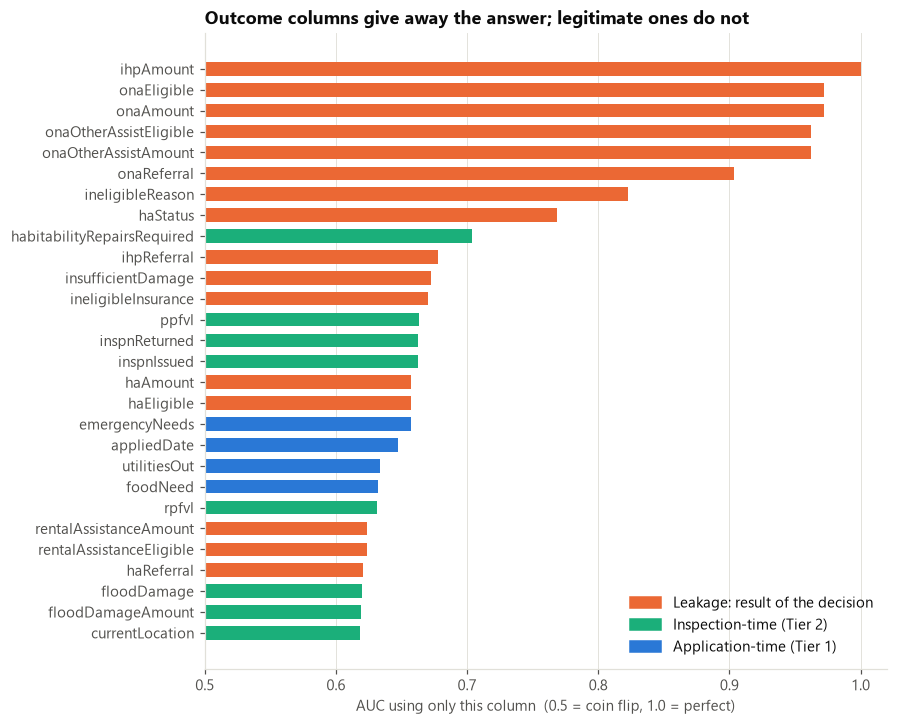

In [8]:
top = auc.head(28).iloc[::-1]
colors = top["role"].map({"leakage": ORANGE, "application": BLUE, "inspection": AQUA}).fillna(GRAY)

fig, ax = plt.subplots(figsize=(8, 7.5))
ax.barh(top.index, top["auc"] - 0.5, left=0.5, color=colors, height=0.65)
ax.axvline(0.5, color=GRAY, lw=1)
ax.set_xlim(0.5, 1.02)
ax.set_xlabel("AUC using only this column  (0.5 = coin flip, 1.0 = perfect)")
ax.grid(axis="y", visible=False)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=ORANGE, label="Leakage: result of the decision"),
                   Patch(color=AQUA, label="Inspection-time (Tier 2)"),
                   Patch(color=BLUE, label="Application-time (Tier 1)")], loc="lower right")
ax.set_title("Outcome columns give away the answer; legitimate ones do not")
save_fig("leakage_auc"); plt.show()

**So what:**
- Columns we labeled **leakage** dominate the top (`ihpAmount` = 1.000, `onaEligible` ≈ 0.97, `ineligibleReason` ≈ 0.83). A model allowed to see them would look brilliant and be useless: it would only be reading the answer key.
- Honest application-time columns top out around **0.66** and inspection-time ones around **0.70** on their own (the top inspection column, `habitabilityRepairsRequired`, is blank for 73% of rows, so part of its signal is *whether it was filled in*). That is realistic, and it means a good model has to **combine many weak signals**, which is exactly what ML is for.
- This is the justification for our two feature tiers. Tier 1 asks *"can FEMA predict eligibility the moment an application arrives?"* Tier 2 adds what an inspector finds.

## 5. Data quality assessment

### 5a. Constant and identifier columns

In [9]:
n_unique = raw.nunique(dropna=False)
constant = n_unique[n_unique == 1].index.tolist()
print(f"{len(constant)} columns have exactly one value on every row:\n  {constant}")
print(f"\n'id' is unique per row: {raw['id'].is_unique}  (an identifier, so never a feature)")

14 columns have exactly one value on every row:
  ['incidentTypeCode', 'declarationDate', 'disasterNumber', 'county', 'fips', 'censusYear', 'damagedStateAbbreviation', 'foundationDamage', 'foundationDamageAmount', 'roofDamage', 'roofDamageAmount', 'ihpMax', 'onaMax', 'lastRefresh']

'id' is unique per row: True  (an identifier, so never a feature)


### 5b. Missing values
Missing data is not random here: often "blank" means *the question was never asked* (e.g. `renterDamageLevel` only applies to renters), not that someone forgot.

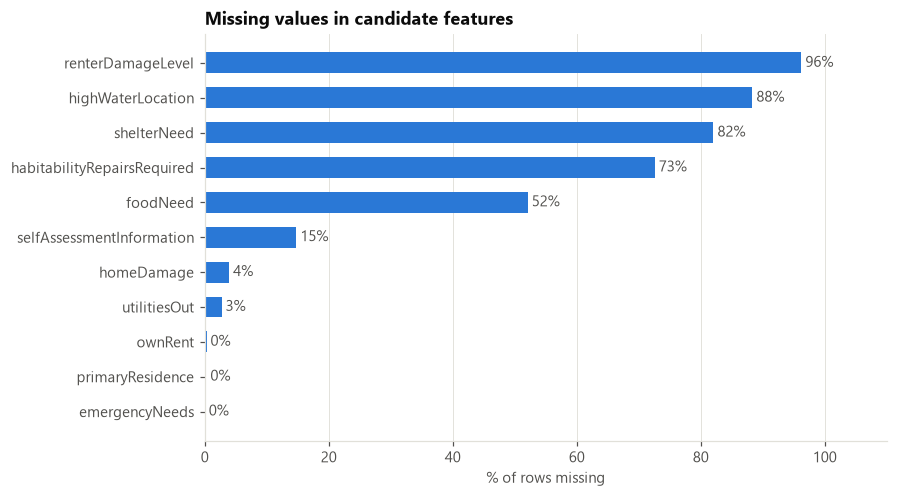

19 columns have any missing values; 11 of them are candidate features.
Columns >90% empty (leakage columns, excluded anyway): ['rentalResourceZipCode', 'rentalResourceCity', 'rentalResourceStateAbbrev', 'rentalAssistanceEndDate']


In [10]:
miss = (raw.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
model_cols = APPLICATION_FEATURES + INSPECTION_FEATURES
usable = miss[miss.index.isin(model_cols)]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(usable.index[::-1], usable.values[::-1], color=BLUE, height=0.6)
for y_, v in enumerate(usable.values[::-1]):
    ax.text(v, y_, f" {v:.0f}%", va="center", color=INK_SOFT)
ax.set_xlim(0, 110); ax.grid(axis="y", visible=False)
ax.set_xlabel("% of rows missing")
ax.set_title("Missing values in candidate features")
save_fig("missing_values"); plt.show()
print(f"{(miss > 0).sum()} columns have any missing values; {len(usable)} of them are candidate features.")
print("Columns >90% empty (leakage columns, excluded anyway):", [c for c in miss[miss > 90].index if c in LEAKAGE])

**So what:** most candidate features are complete. Six have more than 10% missing (`renterDamageLevel`, `highWaterLocation`, `shelterNeed`, `habitabilityRepairsRequired`, `foodNeed`, `selfAssessmentInformation`).
The blanks carry meaning. `renterDamageLevel` and `highWaterLocation` only apply to some applicants, and `foodNeed` / `shelterNeed` are `True` on virtually every row where they are filled in, so a blank effectively means "need not reported". Because of this we will keep an explicit *missing* indicator rather than guess a value (see the Data Preparation Plan).

### 5c. Duplicates, dates, and geography

In [11]:
no_id = raw.drop(columns=["id", "lastRefresh"])
dups = no_id.duplicated().sum()
print(f"Rows identical on all 98 non-ID columns: {dups:,} ({dups / len(raw):.2%}). Likely different households with the same answers; kept.")

decl = pd.to_datetime(raw["declarationDate"], utc=True).dt.tz_localize(None).iloc[0]
early = (applied < decl).sum()
print(f"Disaster declared {decl.date()}; applications dated before that: {early:,} ({early / len(raw):.2%})")

geoid = raw["censusGeoid"].astype(str)
not_lee = ~geoid.str.startswith("12071")
print(f"Census block IDs outside Lee County (FIPS 12071): {not_lee.sum():,}  -> e.g. {geoid[not_lee].value_counts().head(3).to_dict()}")

zip5 = raw["damagedZipCode"].astype(str)
non_fl = ~zip5.str[:2].isin(["32", "33", "34"])
print(f"ZIP codes outside Florida's 32xxx-34xxx range: {non_fl.sum():,} rows, {zip5[non_fl].nunique()} distinct ZIPs")

city = raw["damagedCity"].astype(str)
variants = city[city.str.contains("MYERS", case=False)].value_counts()
print(f"\n{len(variants)} different city strings contain 'MYERS'. Some are genuinely different places (North Fort Myers, Fort Myers Beach); the rare ones are abbreviations/typos (FEMA: city is user-entered, no spell check). Least common:")
print(variants.tail(6).to_string())

Rows identical on all 98 non-ID columns: 407 (0.21%). Likely different households with the same answers; kept.
Disaster declared 2022-09-29; applications dated before that: 2 (0.00%)
Census block IDs outside Lee County (FIPS 12071): 6,357  -> e.g. {'NO_INTERSECT': 2707, '120210101141': 60, '120210101142': 41}
ZIP codes outside Florida's 32xxx-34xxx range: 17 rows, 15 distinct ZIPs

27 different city strings contain 'MYERS'. Some are genuinely different places (North Fort Myers, Fort Myers Beach); the rare ones are abbreviations/typos (FEMA: city is user-entered, no spell check). Least common:
damagedCity
FTMYERS               1
KONORTH FORT MYERS    1
NO FT MYERS           1
NORTFORT MYERS        1
FORTH MYERS           1
NORTHFORTMYERS        1


**So what:** the data is largely clean but has real-world flaws we will handle and document:
- About **3% of rows (6,357)** have a census block outside Lee County: 2,707 are `NO_INTERSECT` (the address did not match any census block) and most of the rest are neighboring counties such as Collier (FIPS 12021). Only 17 rows have a non-Florida ZIP code. We keep them (they are real applicants in the Lee County declaration) and treat unmatched blocks as their own category.
- **City names are unreliable:** FEMA says the field is user-entered with no spell check, and we see abbreviations like `FT MYERS` and `FT MYERS BCH` next to the full names. We drop `damagedCity` and use ZIP code and census block instead.
- Only 2 applications are dated before the declaration; kept, but noted.

### 5d. Outliers in the money and damage columns

In [12]:
cols = ["rpfvl", "ppfvl", "waterLevel", "floodDamageAmount"]
pos = raw[cols].where(raw[cols] > 0)
summary = pd.DataFrame({
    "% zero": (raw[cols] == 0).mean().mul(100).round(1),
    "median (if >0)": pos.median().round(0),
    "95th pct (if >0)": pos.quantile(.95).round(0),
    "max": raw[cols].max().round(0),
})
print(summary.to_string())

                   % zero  median (if >0)  95th pct (if >0)       max
rpfvl                83.2         12375.0          203785.0  214565.0
ppfvl                80.9          3749.0            6696.0   13895.0
waterLevel           88.3            19.0              86.0     960.0
floodDamageAmount    86.6         16827.0          210282.0  218144.0


**So what:** these damage measures are **zero for most people and extremely right-skewed** for the rest (a few very large values). Any linear or distance-based model would be dominated by the extremes, so we plan a `log1p` transform and a "has damage" yes/no indicator. The 960-inch (80 ft) `waterLevel` maximum is physically implausible; a data-entry error we will cap.

## 6. Summary statistics

In [13]:
model = load_model_data("inspection")    # cleaned table: target + Tier 1 + Tier 2 features
num = model.drop(columns=[TARGET]).select_dtypes("number").astype("float64")
desc = num.describe().T[["count", "mean", "std", "min", "50%", "max"]]
desc["missing %"] = (1 - desc["count"] / len(model)) * 100
print(f"Numeric / yes-no features: {len(desc)}")
desc.round(2)

Numeric / yes-no features: 30


,count,mean,std,min,50%,max,missing %
applicantAge,194482.0,2.65,1.07,0.0,3.0,4.00,0.00
householdComposition,194482.0,2.29,1.35,1.0,2.0,6.00,0.00
occupantsUnderTwo,194482.0,0.05,0.23,0.0,0.0,6.00,0.00
occupants2to5,194482.0,0.11,0.36,0.0,0.0,5.00,0.00
occupants6to18,194482.0,0.37,0.80,0.0,0.0,6.00,0.00
occupants19to64,194482.0,1.33,1.02,0.0,1.0,6.00,0.00
occupants65andOver,194482.0,0.45,0.70,0.0,0.0,5.00,0.00
primaryResidence,193981.0,0.94,0.24,0.0,1.0,1.00,0.26
homeOwnersInsurance,194482.0,0.51,0.50,0.0,1.0,1.00,0.00
floodInsurance,194482.0,0.19,0.39,0.0,0.0,1.00,0.00


In [14]:
cat = model.select_dtypes("category")
tbl = pd.DataFrame({
    "distinct values": cat.nunique(),
    "most common": cat.apply(lambda s: s.value_counts().index[0]),
    "its share %": cat.apply(lambda s: s.value_counts(normalize=True).iloc[0] * 100).round(1),
    "missing %": (cat.isna().mean() * 100).round(1),
})
print(f"Categorical features: {len(tbl)}")
tbl

Categorical features: 10


,distinct values,most common,its share %,missing %
grossIncome,7,"$30,001-$60,000",26.3,0.0
ownRent,2,O,64.6,0.3
residenceType,12,H,66.3,0.0
registrationMethod,4,I,38.8,0.0
damagedZipCode,560,33908,8.5,0.0
censusGeoid,3038,NO_INTERSECT,1.4,0.0
selfAssessmentInformation,5,1,53.7,14.8
highWaterLocation,9,1,91.3,88.3
renterDamageLevel,3,5530,80.9,96.2
currentLocation,15,D,67.8,0.0


**So what:** we have a healthy mix of numeric and categorical features (requirement met). Two categorical columns are **high-cardinality**: ZIP code (~560 values) and census block group (~3,000). One-hot encoding those would explode the column count, so the plan uses frequency/target encoding or grouping rare values.

## 7. Distributions: who applied?

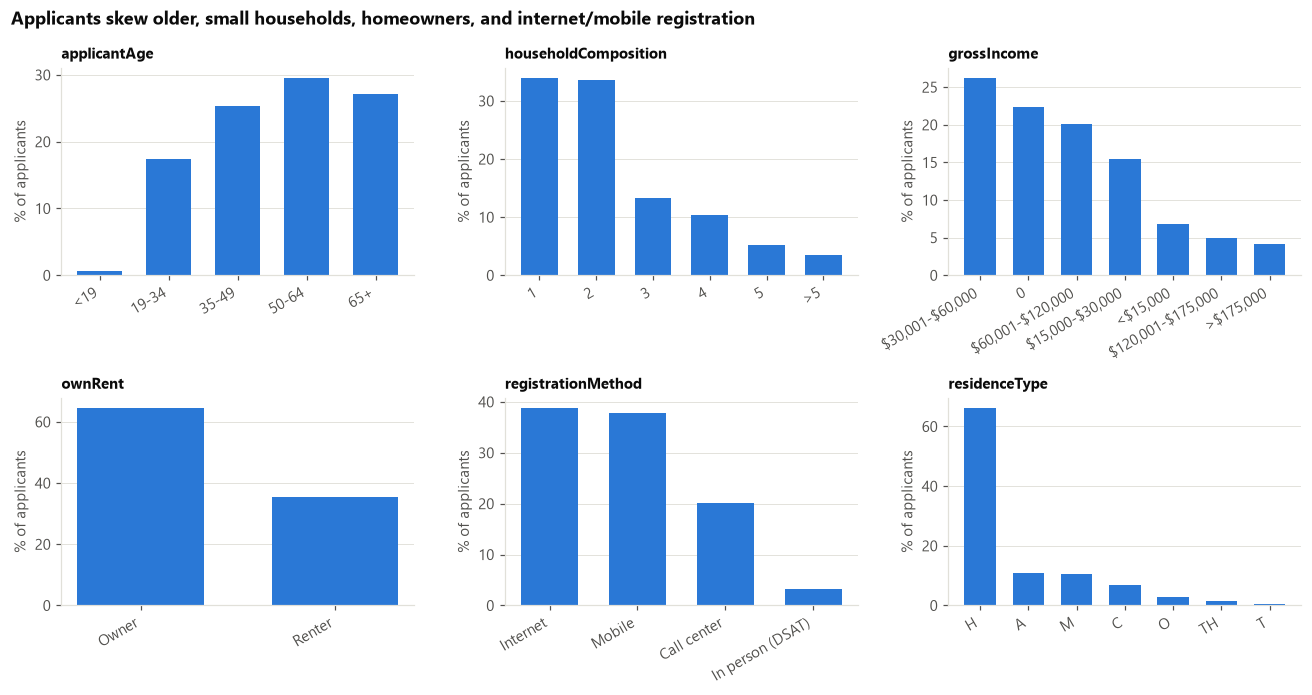

In [15]:
AGE = {0: "<19", 1: "19-34", 2: "35-49", 3: "50-64", 4: "65+"}
CNT = {0: "0", 1: "1", 2: "2", 3: "3", 4: "4", 5: "5", 6: ">5"}
panels = [("applicantAge", AGE), ("householdComposition", CNT), ("grossIncome", None),
          ("ownRent", {"O": "Owner", "R": "Renter"}), ("registrationMethod", {"I": "Internet", "M": "Mobile", "C": "Call center", "D": "In person (DSAT)"}),
          ("residenceType", None)]
fig, axes = plt.subplots(2, 3, figsize=(12, 6.4))
for ax, (col, lab) in zip(axes.ravel(), panels):
    v = model[col].value_counts(normalize=True).mul(100)
    if col in ("applicantAge", "householdComposition"):
        v = v.sort_index()
    else:
        v = v.head(7)
    labels = [str((lab or {}).get(i, i)).replace("$", "\\$") for i in v.index]
    ax.bar(range(len(v)), v.values, color=BLUE, width=0.65)
    ax.set_xticks(range(len(v))); ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_title(col, fontsize=10); ax.grid(axis="x", visible=False)
    ax.set_ylabel("% of applicants")
fig.suptitle("Applicants skew older, small households, homeowners, and internet/mobile registration", x=0.01, ha="left", fontweight="bold")
plt.tight_layout(); save_fig("applicant_profile"); plt.show()

**So what:** more than half of applicants are 50 or older, most households are 1-2 people, about two-thirds own their home, and over three-quarters registered online or by phone app. Our results describe **this** population; they should not be assumed to hold for younger, renter-heavy, or urban disasters.

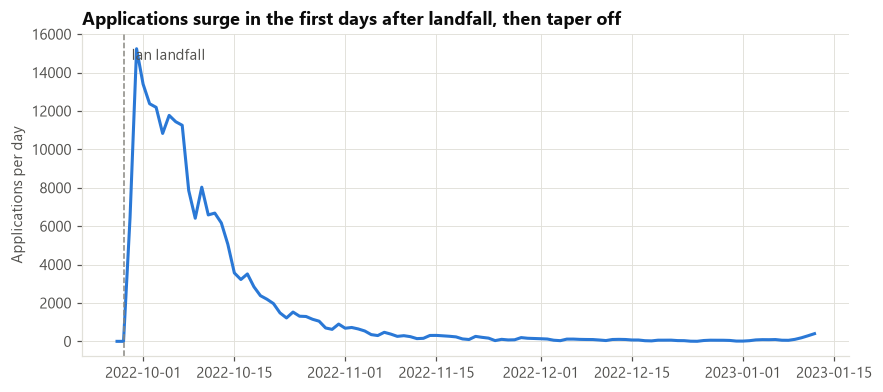

Peak day: 2022-09-30 with 15,240 applications; 94% arrived by Oct 31.


In [16]:
daily = applied.dt.normalize().value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(daily.index, daily.values, color=BLUE, lw=2)
ax.set_ylabel("Applications per day"); ax.set_xlabel("")
ax.set_title("Applications surge in the first days after landfall, then taper off")
ax.axvline(pd.Timestamp("2022-09-28"), color=GRAY, lw=1, ls="--")
ax.text(pd.Timestamp("2022-09-28"), daily.max(), "  Ian landfall", color=INK_SOFT, va="top")
save_fig("applications_over_time"); plt.show()
print(f"Peak day: {daily.idxmax().date()} with {daily.max():,} applications; {(daily.loc[:pd.Timestamp('2022-10-31')].sum() / daily.sum()):.0%} arrived by Oct 31.")

## 8. How do features relate to eligibility?
Each bar is the **% of applicants in that group who were eligible**; the dashed line is the overall rate. Bars far from the line mark features with real signal. (Groups with fewer than 200 applicants are skipped as unreliable.)

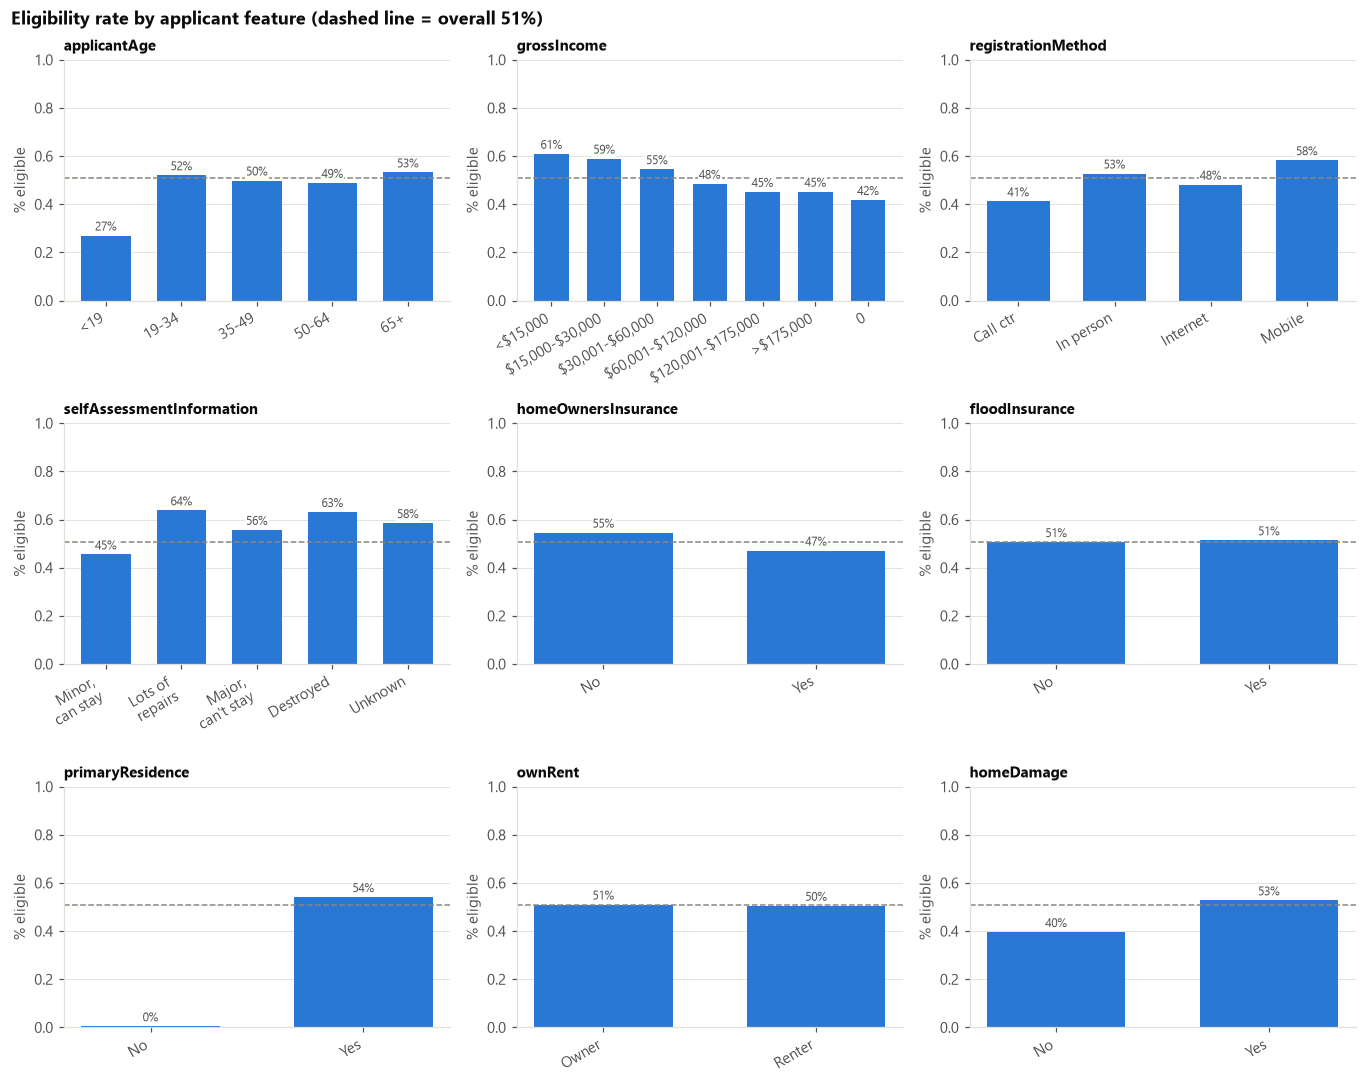

In [17]:
overall = model[TARGET].mean()
YN = {0: "No", 1: "Yes"}

def rate_bar(ax, col, labels=None, order=None):
    g = model.groupby(col, observed=True)[TARGET].agg(["mean", "size"])
    g = g[g["size"] >= 200]
    if order is not None:
        g = g.reindex([o for o in order if o in g.index])
    x = [str((labels or {}).get(i, str(i))).replace("$", "\\$") for i in g.index]
    ax.bar(range(len(g)), g["mean"], color=BLUE, width=0.65)
    for i, m in enumerate(g["mean"]):
        ax.text(i, m + 0.01, f"{m:.0%}", ha="center", va="bottom", fontsize=8, color=INK_SOFT,
                bbox=dict(fc="white", ec="none", pad=0.6))
    ax.axhline(overall, color=GRAY, lw=1, ls="--")
    ax.set_xticks(range(len(g))); ax.set_xticklabels(x, rotation=30, ha="right")
    ax.set_ylim(0, 1.0); ax.set_title(col, fontsize=10); ax.grid(axis="x", visible=False)
    ax.set_ylabel("% eligible")

SELF = {"1": "Minor,\ncan stay", "2": "Lots of\nrepairs", "3": "Major,\ncan't stay", "4": "Destroyed", "5": "Unknown"}
INC = ["<$15,000", "$15,000-$30,000", "$30,001-$60,000", "$60,001-$120,000", "$120,001-$175,000", ">$175,000", "0"]
fig, axes = plt.subplots(3, 3, figsize=(12.5, 10))
rate_bar(axes[0, 0], "applicantAge", AGE)
rate_bar(axes[0, 1], "grossIncome", order=INC)
rate_bar(axes[0, 2], "registrationMethod", {"I": "Internet", "M": "Mobile", "C": "Call ctr", "D": "In person"})
rate_bar(axes[1, 0], "selfAssessmentInformation", SELF)
rate_bar(axes[1, 1], "homeOwnersInsurance", YN)
rate_bar(axes[1, 2], "floodInsurance", YN)
rate_bar(axes[2, 0], "primaryResidence", YN)
rate_bar(axes[2, 1], "ownRent", {"O": "Owner", "R": "Renter"})
rate_bar(axes[2, 2], "homeDamage", YN)
fig.suptitle("Eligibility rate by applicant feature (dashed line = overall 51%)", x=0.01, ha="left", fontweight="bold")
plt.tight_layout(); save_fig("eligibility_by_feature"); plt.show()

**So what:**
- **Primary residence is close to a hard rule:** FEMA's IHP only covers a primary home, so non-primary homes are almost never eligible.
- **Owner vs renter barely matters** (both ≈ 51%), which surprised us; we'd have expected a gap.
- **Homeowners insurance *lowers* eligibility**, consistent with FEMA covering only what insurance doesn't. **Flood insurance** makes little difference.
- **Lower reported income means higher eligibility** (61% for under $15k down to 45% above $175k), except the "$0" group, which is the *lowest* (42%). Since "$0" breaks the ordering, we keep income as an unordered category rather than a number.
- Fairness note for the report: age and income are legitimate FEMA screening inputs, but any deployed model must be audited for unequal error rates across groups.

Now the Tier 2 (post-inspection) columns, which are much stronger:

In [18]:
rows = []
for col, lab in [("inspnIssued", "Inspection issued"), ("inspnReturned", "Inspection completed"), ("destroyed", "Home destroyed"),
                 ("verifiedOccupancy", "Occupancy verified"), ("verifiedOwnership", "Ownership verified"), ("floodDamage", "Flood damage recorded")]:
    for v, g in model.groupby(col, observed=True)[TARGET]:
        rows.append({"feature": lab, "value": "Yes" if v == 1 else "No", "applicants": len(g), "% eligible": round(g.mean() * 100, 1)})
pd.DataFrame(rows).pivot(index="feature", columns="value", values="% eligible")

value,No,Yes
feature,,
Flood damage recorded,43.9,94.0
Home destroyed,50.0,98.7
Inspection completed,37.8,73.3
Inspection issued,37.8,73.3
Occupancy verified,0.6,54.8
Ownership verified,47.1,53.5


**So what:** an inspector's visit is a strong signal: applicants whose inspection was completed are ~73% eligible vs ~38% otherwise, and unverified occupancy is essentially a dead end (<1% eligible). Tier 2 should therefore score noticeably higher than Tier 1, at the cost of arriving later in the process.

### Geography and timing

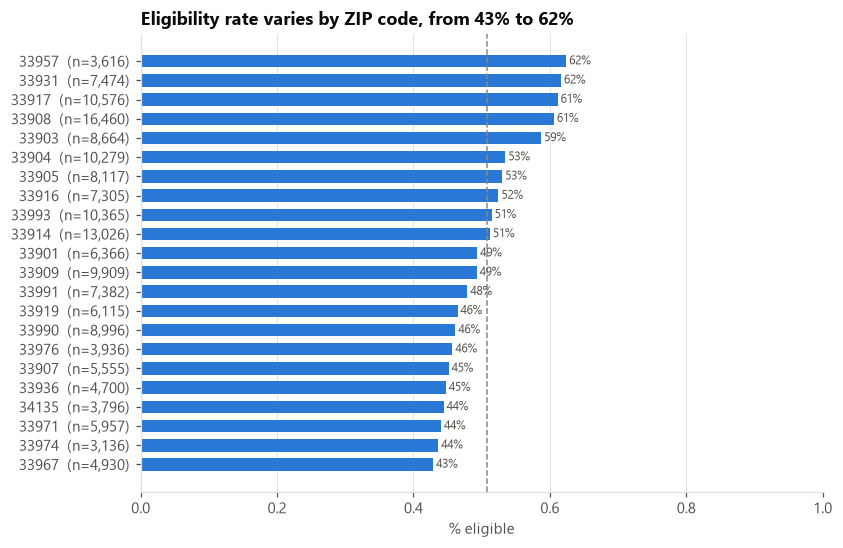

22 ZIPs with 3,000+ applicants; eligibility ranges 43% to 62%.


In [19]:
z = model.groupby("damagedZipCode", observed=True)[TARGET].agg(["mean", "size"])
z = z[z["size"] >= 3000].sort_values("mean")
fig, ax = plt.subplots(figsize=(8, 5.4))
ax.barh([f"{i}  (n={int(n):,})" for i, n in zip(z.index, z["size"])], z["mean"], color=BLUE, height=0.65)
ax.axvline(overall, color=GRAY, lw=1, ls="--")
for y_, m in enumerate(z["mean"]):
    ax.text(m, y_, f" {m:.0%}", va="center", color=INK_SOFT, fontsize=8)
ax.set_xlim(0, 1); ax.grid(axis="y", visible=False); ax.set_xlabel("% eligible")
ax.set_title(f"Eligibility rate varies by ZIP code, from {z['mean'].min():.0%} to {z['mean'].max():.0%}")
save_fig("eligibility_by_zip"); plt.show()
print(f"{len(z)} ZIPs with 3,000+ applicants; eligibility ranges {z['mean'].min():.0%} to {z['mean'].max():.0%}.")

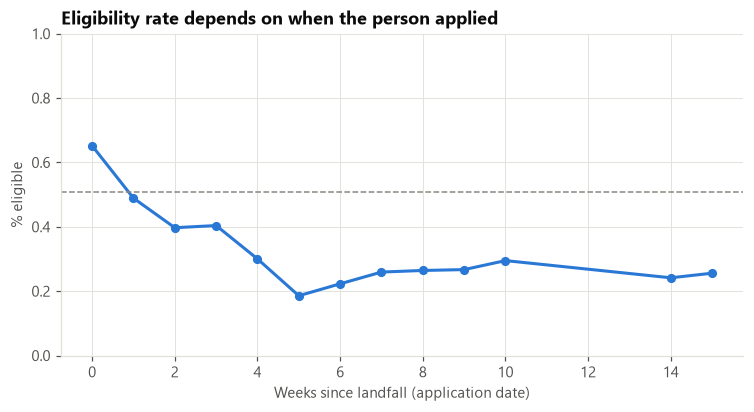

In [20]:
wk = model.assign(week=model["daysSinceLandfall"] // 7).groupby("week")[TARGET].agg(["mean", "size"])
wk = wk[wk["size"] >= 500]
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(wk.index, wk["mean"], color=BLUE, lw=2, marker="o", ms=5)
ax.axhline(overall, color=GRAY, lw=1, ls="--")
ax.set_ylim(0, 1); ax.set_xlabel("Weeks since landfall (application date)"); ax.set_ylabel("% eligible")
ax.set_title("Eligibility rate depends on when the person applied")
save_fig("eligibility_by_week"); plt.show()

**So what:** location and timing both carry signal, so **geography (ZIP / census block) and application date are worth keeping**. They are also where *drift* could bite: because Ian was one storm, a model trained here should not be assumed to transfer to a different disaster or a different time in the response.

## 9. Correlation analysis
Pearson correlation on numeric and yes/no features (categorical columns are covered by the group rates above). Range −1 to +1; blue = moves *with* eligibility, red = moves *against* it.

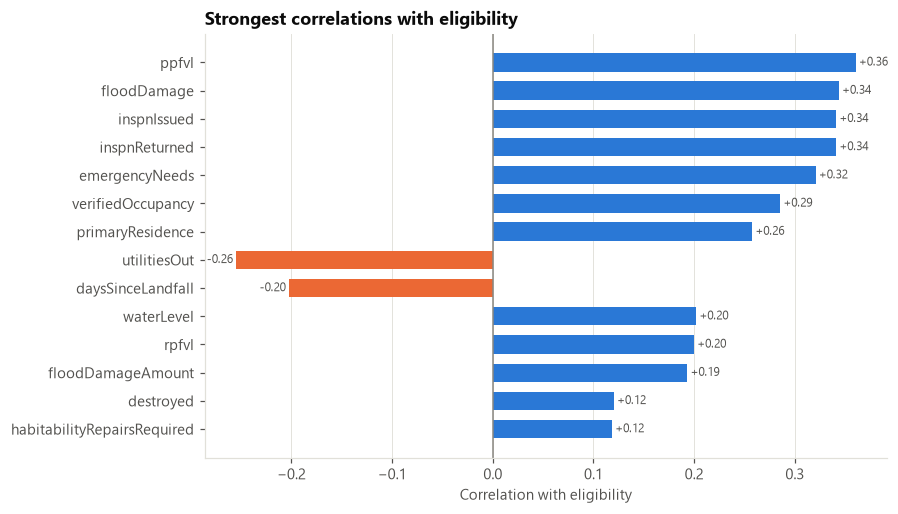

In [21]:
numf = model.select_dtypes("number").astype("float64")
corr = numf.corr()
t = corr[TARGET].drop(TARGET).dropna()
t = t.reindex(t.abs().sort_values(ascending=False).index).head(14).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(t.index, t.values, color=[BLUE if v > 0 else ORANGE for v in t.values], height=0.65)
ax.axvline(0, color=GRAY, lw=1)
for y_, v in enumerate(t.values):
    ax.text(v, y_, f" {v:+.2f}" if v > 0 else f"{v:+.2f} ", va="center", ha="left" if v > 0 else "right", color=INK_SOFT, fontsize=8)
ax.set_xlabel("Correlation with eligibility"); ax.grid(axis="y", visible=False)
ax.set_title("Strongest correlations with eligibility")
save_fig("correlation_with_target"); plt.show()

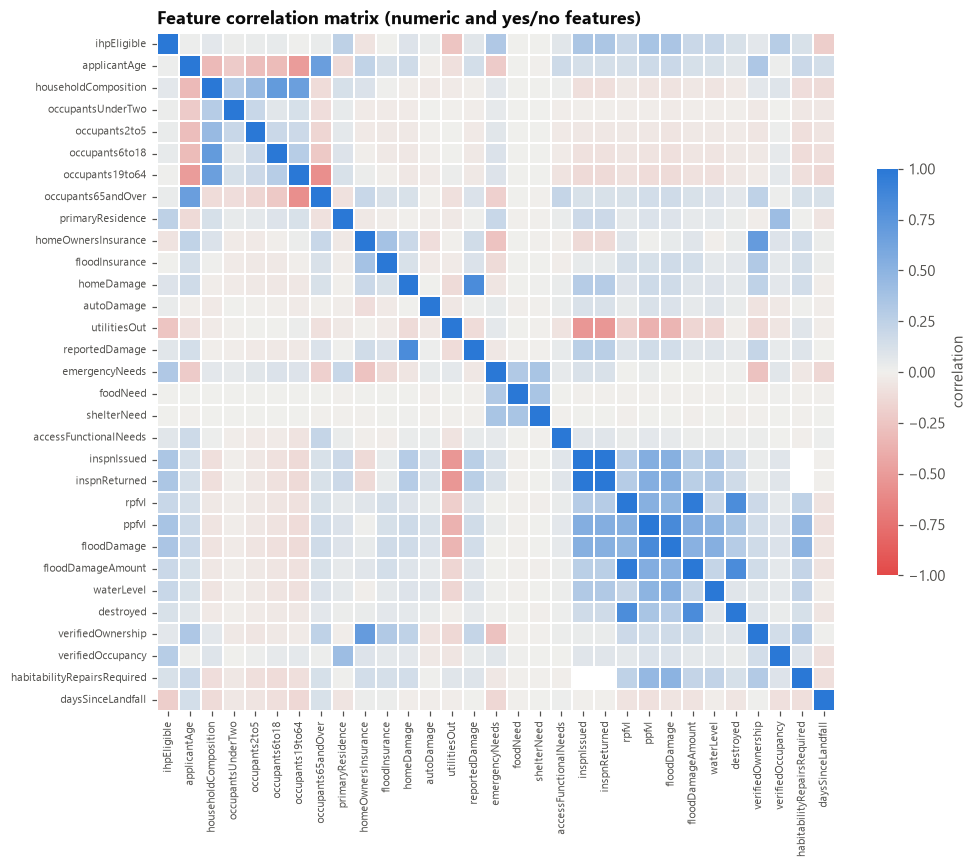

Feature pairs that are nearly the same information (|r| > 0.7):
inspnIssued           inspnReturned        1.00
rpfvl                 floodDamageAmount    0.97
ppfvl                 floodDamage          0.85
homeDamage            reportedDamage       0.83
floodDamageAmount     destroyed            0.83
rpfvl                 destroyed            0.83
householdComposition  occupants6to18       0.71
homeOwnersInsurance   verifiedOwnership    0.70


In [22]:
div = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap=div, vmin=-1, vmax=1, center=0, square=True, linewidths=0.3, linecolor="white",
            cbar_kws={"shrink": 0.6, "label": "correlation"}, ax=ax)
ax.set_title("Feature correlation matrix (numeric and yes/no features)")
ax.tick_params(labelsize=7); ax.grid(False)
save_fig("correlation_matrix"); plt.show()

upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
strong = upper[upper.abs() > 0.7].sort_values(key=abs, ascending=False)
print("Feature pairs that are nearly the same information (|r| > 0.7):")
print(strong.round(2).to_string() if len(strong) else "none")

**So what:** no single numeric feature correlates strongly with eligibility (the strongest is about 0.36), which matches the leakage check: prediction has to come from combining features. Several feature *pairs* are near-duplicates (printout above), e.g. inspection issued vs completed (1.00), real-property loss vs flood-damage amount (0.97), and reported damage vs home damage (0.83). We will drop one of each pair for linear models and let tree models handle the rest.

## 10. Preliminary check: is this predictable, and why?
Before planning models we ran two quick checks. (These are *untuned* baselines scored on the **validation** split only. The test set stays untouched until the end of Milestone 2.)

**First, what does an award look like?** If awards cluster on a few fixed amounts, eligibility may be driven by simple rules.

In [23]:
el = raw[raw[TARGET]]
top = el["ihpAmount"].value_counts().head(5)
tbl = pd.DataFrame({"applicants": top, "% of all eligible": (top / len(el) * 100).round(1)})
tbl.index = [f"${v:,.0f}" for v in tbl.index]
tbl.index.name = "award amount"
print(tbl.to_string())

need = raw.groupby("emergencyNeeds")[TARGET].agg(["mean", "size"])
print("\n% eligible by 'reported emergency needs':")
print((need["mean"] * 100).round(1).rename({False: "No", True: "Yes"}).to_string())

              applicants  % of all eligible
award amount                               
$700               45192               45.8
$1,000             12542               12.7
$300                8129                8.2
$3,602              3613                3.7
$2,982              2653                2.7

% eligible by 'reported emergency needs':
emergencyNeeds
No     33.6
Yes    65.7


**So what:** nearly half of all eligible applicants received *exactly $700*, and reporting emergency needs takes eligibility from about a third to about two-thirds. That looks like a **flat emergency-needs payment** that many applicants qualified for automatically. This is our reading of the pattern, and the team should confirm it against FEMA's program documentation. If it's right, part of the model's job is to learn FEMA's own screening rules, which is a legitimate and explainable task.

**Second, is the location field safe?** `currentLocation` records where the applicant is staying. Some values are places people end up *after* receiving help:

In [24]:
loc = raw.groupby("currentLocation")[TARGET].agg(["mean", "size"])
loc = loc[loc["size"] >= 250].sort_values("mean", ascending=False)
LOC = {"MHU": "FEMA-provided unit", "R": "New temporary rental", "RVT": "RV / camper", "P": "Purchased new home",
       "PRU": "New permanent rental", "F": "Family / friends", "D": "My home", "H": "Hotel / motel", "SR": "Secondary residence",
       "NH": "Homeless", "S": "Mass shelter", "E": "Place of employment", "C": "My vehicle", "T": "Tent", "CH": "Church"}
loc.index = [f"{LOC.get(i, i)} ({i})" for i in loc.index]
loc["% eligible"] = (loc["mean"] * 100).round(1)
print(loc[["% eligible", "size"]].rename(columns={"size": "applicants"}).to_string())

                            % eligible  applicants
FEMA-provided unit (MHU)          98.6         277
New temporary rental (R)          87.1        5375
RV / camper (RVT)                 81.6        1771
Purchased new home (P)            79.0         381
New permanent rental (PRU)        77.4        1093
Place of employment (E)           73.1         360
Family / friends (F)              69.7       31467
My vehicle (C)                    59.8         799
My home (D)                       46.7      131931
Mass shelter (S)                  40.3         789
Secondary residence (SR)          36.3        7170
Homeless (NH)                     36.0        1487
Hotel / motel (H)                 29.1       11229


**So what:** "FEMA-provided unit" is 99% eligible and "new rental" 87%. These are almost certainly *consequences* of aid, and the field can be updated after registration. We therefore moved `currentLocation` **out of Tier 1** (it now sits in the later-stage Tier 2). Removing it costs only ~0.013 AUC, a small price for a much safer model.

**Now the baselines:**

In [25]:
from src.models.baseline import run_baselines

for tier in ("application", "inspection"):
    label = "Tier 1: at application time" if tier == "application" else "Tier 1 + Tier 2: after inspection"
    print(f"\n{label}")
    print(run_baselines(tier).to_string())


Tier 1: at application time


                                 features  ROC-AUC  accuracy     F1
model                                                              
Gradient boosting                      26    0.900     0.824  0.837
Logistic regression                    26    0.843     0.764  0.771
Always guess the majority class        26    0.500     0.507  0.000

Tier 1 + Tier 2: after inspection


                                 features  ROC-AUC  accuracy     F1
model                                                              
Gradient boosting                      40    0.938     0.870  0.882
Logistic regression                    40    0.898     0.818  0.825
Always guess the majority class        40    0.500     0.507  0.000


**So what:**
- **The problem is very learnable.** Untuned gradient boosting reaches an **AUC of about 0.90 using only application-time answers** and about 0.94 once inspection results are added. Always guessing the majority class gives 50.7% accuracy; the boosted model is at roughly 82% (Tier 1) and 87% (Tier 2).
- **Gradient boosting beats logistic regression by 4-6 AUC points**, so interactions between features matter (e.g. emergency needs combined with occupancy and residence status), not just individual effects.
- **This must not be read as "AI can decide who deserves aid".** The strong score partly reflects that FEMA's own eligibility rules are fairly mechanical, and the model is learning those rules. That is useful for *triage and explaining outcomes*, not for replacing caseworkers. This shapes the Business Understanding section.
- Because the score is high, **leakage hunting matters even more**. We found and removed one suspect column here; Milestone 2 should repeat the ablation check (drop a feature group, see how the score moves) for every final feature set.

## 11. Key findings, challenges, and limitations

In [26]:
best_legit = auc[auc["role"].isin(["application", "inspection"])]["auc"].max()
best_leak = auc[auc["role"] == "leakage"]["auc"].max()
print("KEY NUMBERS")
print(f"  Rows / columns .................. {raw.shape[0]:,} / {raw.shape[1]}")
print(f"  Target balance .................. {raw[TARGET].mean():.1%} eligible")
print(f"  Leakage columns ................. {len(LEAKAGE)} of {raw.shape[1]} (best single-column AUC {best_leak:.3f})")
print(f"  Usable features ................. {len(APPLICATION_FEATURES)} application-time + {len(INSPECTION_FEATURES)} inspection-time")
print(f"  Best legitimate single column ... AUC {best_legit:.3f}  ({auc[auc['role'].isin(['application','inspection'])]['auc'].idxmax()})")
print(f"  Constant / ID columns ........... {len(constant)}")
print(f"  Duplicate-looking rows .......... {dups:,}")

KEY NUMBERS
  Rows / columns .................. 194,482 / 100
  Target balance .................. 50.7% eligible
  Leakage columns ................. 43 of 100 (best single-column AUC 1.000)
  Usable features ................. 27 application-time + 14 inspection-time
  Best legitimate single column ... AUC 0.703  (habitabilityRepairsRequired)
  Constant / ID columns ........... 14
  Duplicate-looking rows .......... 407


**Findings**
1. The data comfortably meets the project requirements: ~194k rows, 100 columns, mixed numeric/categorical.
2. **Target `ihpEligible` is naturally balanced** (~51/49), so accuracy is meaningful.
3. **Leakage is the central risk:** 43 of 100 columns are outcomes of the decision, and one more (`currentLocation`) was moved out of Tier 1 after testing. We isolate all of this in one file (`src/utils/columns.py`) so no teammate uses a leaky column by accident.
4. Honest features are individually weak (best single column AUC about 0.70) but **strong in combination**: an untuned boosting model reaches AUC about 0.90 from application-time answers and about 0.94 after inspection.
5. Emergency-needs answers, primary-residence status, insurance, inspection results, and application timing carry the most signal. Nearly half of all awards are exactly $700, which suggests a flat emergency-needs payment (to confirm with FEMA documentation).

**Challenges and limitations (for the report)**
- *Rule-driven outcome:* because eligibility partly follows FEMA's own screening rules, a high score does not mean the model "understands need". It shows the model can reproduce the process, and it should support caseworkers, not replace them.
- *Scope:* one disaster, one county: results describe Ian in Lee County and may not generalize.
- *Selection:* only **valid registrants** are included; we cannot say anything about invalid applications.
- *Label meaning:* "not eligible" bundles many reasons (insurance, no documents, withdrew, duplicate, never referred).
- *Source noise:* operational data with human-entry error (city spellings, a few out-of-county addresses, implausible water depths).
- *Heavy skew and structural missingness* in damage and need columns.
- *High-cardinality geography* (ZIP, census block) needs careful encoding to avoid overfitting.
- *Fairness:* age, income and location correlate with protected or vulnerable groups; the final report must evaluate error rates across groups.

**Next:** see `src/features/prepare.py` and `src/models/baseline.py` (cleaning + train/validation/test split) and the Data Preparation Plan in the Milestone 1 report.